## Checking of Energy Minimization

In [2]:
import os
data_dir = "/home/admin/gitrepos"
data_dir = os.path.join(data_dir, "gromacs_sims/Antimicrobial_Peptides/Ku04AMP01_Membrane_Bilayer/simulations_cg/simulation_cg_multipeptide")
os.chdir(data_dir)


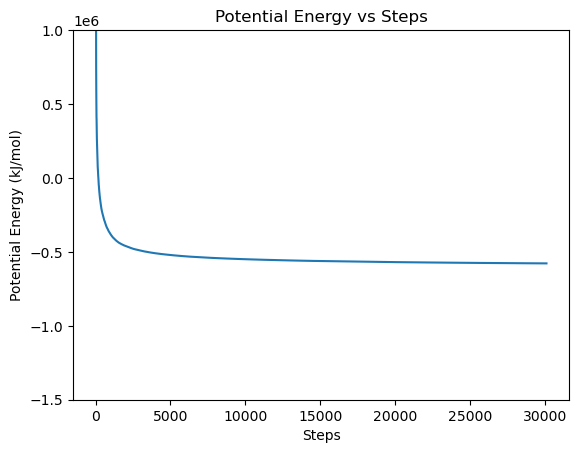

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Load data, skipping lines starting with '@' and '#'
# unpack=True allows you to assign columns directly to x and y
x, y = np.loadtxt("potential.xvg", comments=["@", "#"], unpack=True)

plt.plot(x, y)
plt.title("Potential Energy vs Steps")
plt.xlabel("Steps")
plt.ylabel("Potential Energy (kJ/mol)")
plt.ylim(-1500000, 1000000)  # Set y-axis limits for better visualization
plt.show()

In [5]:
import os 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import MDAnalysis as mda 
from MDAnalysis.analysis import rms 
from multiprocessing import Pool, cpu_count 
from functools import partial 
from tqdm.notebook import tqdm

In [16]:
# ========================================== 
# 1. FILE PATHS & SELECTION CONSTANTS 
# # ========================================== 
top_file = "temp/md_dry.tpr" # or ku04_gim_multi.tpr / ku04_gim_multi.gro 
traj_file = "temp/traj_dry.xtc" # or md.xtc / traj_nojump.xtc

# Selections 
pep_sel = "resname ALA ARG ASN ASP CYS GLU GLN GLY HIS ILE LEU LYS MET PHE PRO SER THR TRP TYR VAL" # or "protein" 
memb_sel = "resname DVPE POPG POPE DOPE TOCL" 

# Note: TOCL in MARTINI 3 has PO41 and PO42 beads 
phos_sel = "(resname DVPE POPG POPE DOPE TOCL) and (name PO4 PO41 PO42)"

# Number of parallel workers 
n_jobs = min(8, cpu_count())

# ========================================== # 2. INITIALIZE UNIVERSE & GET SELECTIONS # ========================================== 
u = mda.Universe(top_file, traj_file) 
n_frames = len(u.trajectory) 
times = np.array([ts.time / 1000.0 for ts in u.trajectory]) # Convert ps -> ns

# Split protein into individual peptide AtomGroups 
protein = u.select_atoms(pep_sel) 
peptides = protein.fragments # Automatically splits by molecule connectivity 
num_peptides = len(peptides)

print(f"Loaded trajectory with {n_frames} frames across {times[-1]:.2f} ns.") 
print(f"Detected {num_peptides} individual peptide molecules.")

# Extract reference positions for each peptide (for RMSD calculation) 
# Stored as list of numpy arrays 
u.trajectory[0] 
ref_pep_positions = [pep.positions.copy() for pep in peptides]

# Chunk trajectory frames into slices for multiprocessing Pool 
chunk_size = max(1, n_frames // n_jobs) 
blocks = [slice(i, min(i + chunk_size, n_frames)) for i in range(0, n_frames, chunk_size)]

Loaded trajectory with 16932 frames across 3386.20 ns.
Detected 12 individual peptide molecules.


## Production PP

First, let's test to ensure that the concatenation worked.

In [22]:
# ==========================================
# 3. WORKER FUNCTIONS FOR MULTIPROCESSING
# ==========================================

def analyze_peptide_z_block(block_slice, top_f, traj_f, p_sel, m_sel, ph_sel):
    """
    Worker: Calculates z-COM of each peptide, membrane midplane,
    and mean upper/lower phosphate planes for a trajectory block.
    """
    u_w = mda.Universe(top_f, traj_f)
    protein_w = u_w.select_atoms(p_sel)
    peptides_w = protein_w.fragments
    memb_w = u_w.select_atoms(m_sel)
    phos_w = u_w.select_atoms(ph_sel)
    
    n_block = block_slice.stop - block_slice.start
    n_peps = len(peptides_w)
    
    z_peps = np.zeros((n_block, n_peps))
    z_mids = np.zeros(n_block)
    z_p_upper = np.zeros(n_block)
    z_p_lower = np.zeros(n_block)
    
    for idx, _ in enumerate(u_w.trajectory[block_slice.start:block_slice.stop]):
        # Membrane COM (midplane z)
        mid_z = memb_w.center_of_mass(unwrap=False)[2] #The membrane is multiple molecules
        z_mids[idx] = mid_z
        
        # Split phosphate beads into upper and lower leaflets based on midplane z
        phos_z = phos_w.positions[:, 2]
        upper_mask = phos_z > mid_z
        lower_mask = phos_z < mid_z
        
        z_p_upper[idx] = phos_z[upper_mask].mean() if np.any(upper_mask) else mid_z
        z_p_lower[idx] = phos_z[lower_mask].mean() if np.any(lower_mask) else mid_z
        
        # Calculate each peptide's z-COM
        for p_idx, pep in enumerate(peptides_w):
            z_peps[idx, p_idx] = pep.center_of_mass(unwrap=True)[2]
            
    u_w.trajectory.close()
    return z_peps, z_mids, z_p_upper, z_p_lower


def analyze_peptide_rmsd_block(block_slice, top_f, traj_f, p_sel, ref_pos_list):
    """
    Worker: Calculates individual peptide RMSDs over a trajectory block.
    """
    u_w = mda.Universe(top_f, traj_f)
    protein_w = u_w.select_atoms(p_sel)
    peptides_w = protein_w.fragments
    
    n_block = block_slice.stop - block_slice.start
    n_peps = len(peptides_w)
    rmsd_array = np.zeros((n_block, n_peps))
    
    for idx, _ in enumerate(u_w.trajectory[block_slice.start:block_slice.stop]):
        for p_idx, pep in enumerate(peptides_w):
            # Calculate RMSD with rigid-body superposition (translation/rotation alignment)
            # Output in Angstroms
            val = rms.rmsd(pep.positions, ref_pos_list[p_idx], superposition=True)
            rmsd_array[idx, p_idx] = val
            
    u_w.trajectory.close()
    return rmsd_array

In [18]:
# ==========================================
# 4. EXECUTE PARALLEL CALCULATIONS
# ==========================================

# 4A. Calculate RMSD Trajectories
print(f"Computing individual peptide RMSDs on {n_jobs} cores...")
run_rmsd_func = partial(
    analyze_peptide_rmsd_block,
    top_f=top_file, traj_f=traj_file,
    p_sel=pep_sel, ref_pos_list=ref_pep_positions
)

with Pool(n_jobs) as pool:
    rmsd_results = list(tqdm(pool.imap(run_rmsd_func, blocks), total=len(blocks), desc="RMSD Blocks"))
    
rmsd_all = np.vstack(rmsd_results) # Shape: (n_frames, num_peptides)
# Convert to nanometres
rmsd_nm   = rmsd_all   / 10.0
# Create DataFrames
pep_cols = [f"Peptide_{i+1}" for i in range(num_peptides)]

df_rmsd = pd.DataFrame(rmsd_nm, columns=pep_cols)
df_rmsd.insert(0, "Time_ns", times)
df_rmsd.to_csv("individual_peptide_rmsd.csv", index=False)


Computing individual peptide RMSDs on 8 cores...


RMSD Blocks:   0%|          | 0/9 [00:00<?, ?it/s]

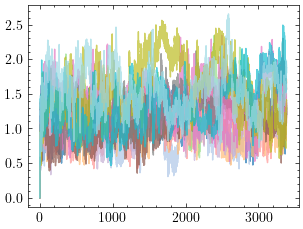

In [19]:
import scienceplots
plt.style.use("science")
# plt.rcParams['text.usetex'] = False
colors = plt.cm.tab20(np.linspace(0, 1, num_peptides))
# --- Plot 2: Individual Peptide RMSD ---
for i in range(num_peptides):
    plt.plot(times, rmsd_nm[:, i], label=f"Pep {i+1}", alpha=0.7, color=colors[i], lw=1.0)

## Peptide center-of-mass depth (MOST IMPORTANT)

This is the primary penetration metric.

Measure:

COM of PMBN
vs
membrane midplane (or phosphate plane).

Plot:

z_peptide(t) - z_membrane_center(t)

Interpretation:

* constant near-water value → no binding

* stable near-headgroup region → adsorption

* gradual inward motion → insertion

* crossing midplane → translocation

### Get headgroup distance 

You can verify the exact headgroup positions for your specific system by calculating the Z-position of the Phosphorus (P) atoms relative to the midplane.

In GROMACS/CHARMM36, Phosphorus atoms (name P) are located in the headgroups of all your lipids (PMPE, POPE, PYPG, etc.). By tracking their COM, you get the objective "surface" of the membrane.

### Get z-COM of peptide

In [23]:
# 4A. Calculate z-COM Trajectories
print(f"Computing z-COM coordinates on {n_jobs} cores...")
run_z_func = partial(
    analyze_peptide_z_block, 
    top_f=top_file, traj_f=traj_file, 
    p_sel=pep_sel, m_sel=memb_sel, ph_sel=phos_sel
)

with Pool(n_jobs) as pool:
    z_results = list(tqdm(pool.imap(run_z_func, blocks), total=len(blocks), desc="z-COM Blocks"))

# Combine block results
z_peps_all = np.vstack([r[0] for r in z_results])       # Shape: (n_frames, num_peptides)
z_mids_all = np.concatenate([r[1] for r in z_results])  # Shape: (n_frames,)
z_pup_all  = np.concatenate([r[2] for r in z_results])  # Upper phosphate plane
z_plow_all = np.concatenate([r[3] for r in z_results])  # Lower phosphate plane

Computing z-COM coordinates on 8 cores...


z-COM Blocks:   0%|          | 0/9 [00:00<?, ?it/s]

### Plot z-COM relative to membrane COM and headgroup planes

<>:53: SyntaxWarning: invalid escape sequence '\&'
<>:53: SyntaxWarning: invalid escape sequence '\&'
/tmp/ipykernel_71650/3710563666.py:53: SyntaxWarning: invalid escape sequence '\&'
  ax1.set_title("Individual Peptide z-COM Distances \& Phosphate Headgroup Planes")


Saved CSV outputs to current working directory.


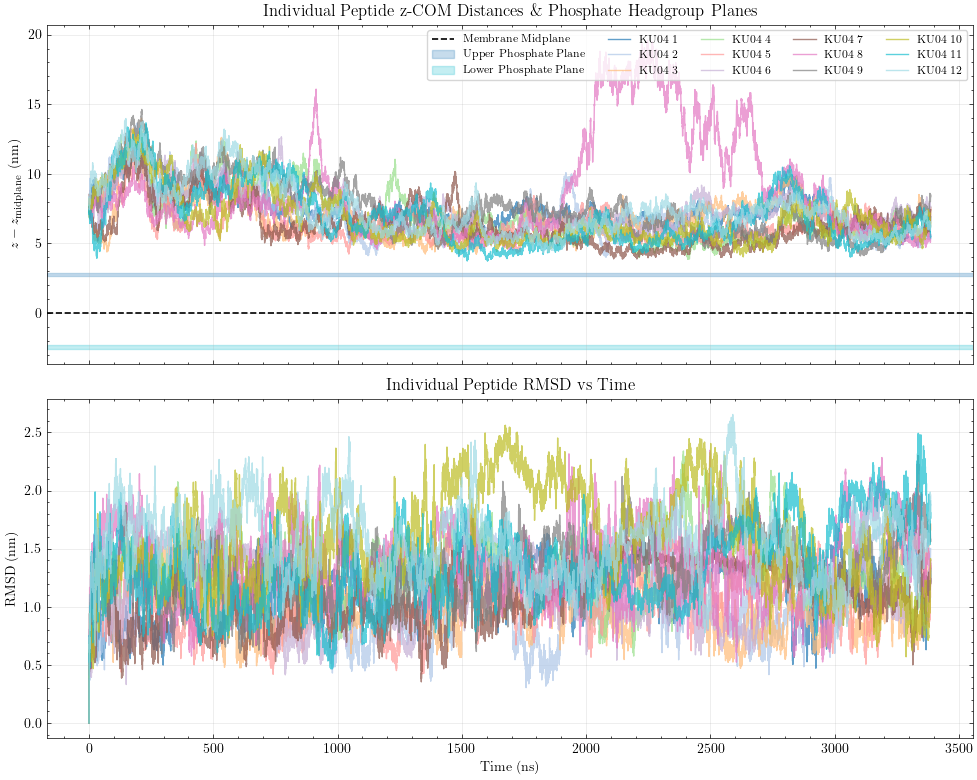

In [28]:
# ==========================================
# 5. CONVERT TO NANOMETERS & DATAFRAMES
# ==========================================

# Convert MDAnalysis Angstroms -> Nanometers (divide by 10)
z_peps_nm = z_peps_all / 10.0
z_mids_nm = z_mids_all / 10.0
z_pup_nm  = z_pup_all  / 10.0
z_plow_nm = z_plow_all / 10.0

# Calculate relative z-distances (nm)
# Distances from upper phosphate plane, lower phosphate plane, and midplane
dz_mid_nm   = z_peps_nm - z_mids_nm[:, np.newaxis]
dz_upper_nm = z_peps_nm - z_pup_nm[:, np.newaxis]
dz_lower_nm = z_peps_nm - z_plow_nm[:, np.newaxis]

# Create DataFrames
pep_cols = [f"Peptide_{i+1}" for i in range(num_peptides)]

df_dz_mid = pd.DataFrame(dz_mid_nm, columns=pep_cols)
df_dz_mid.insert(0, "Time_ns", times)
df_dz_mid.to_csv("individual_peptide_z_midplane.csv", index=False)

df_dz_upper = pd.DataFrame(dz_upper_nm, columns=pep_cols)
df_dz_upper.insert(0, "Time_ns", times)
df_dz_upper.to_csv("individual_peptide_z_upper_phosphate.csv", index=False)

print("Saved CSV outputs to current working directory.")


# ==========================================
# 6. PUBLICATION-QUALITY PLOTTING
# ==========================================
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True, tight_layout=True)

# --- Plot 1: Peptide z-COM relative to Phosphate Planes ---
ax1.axhline(0, color="black", linestyle="--", linewidth=1.2, label="Membrane Midplane")

# Plot upper and lower phosphate plane bands
avg_pup = (z_pup_nm - z_mids_nm).mean()
std_pup = (z_pup_nm - z_mids_nm).std()
avg_plow = (z_plow_nm - z_mids_nm).mean()
std_plow = (z_plow_nm - z_mids_nm).std()

ax1.axhspan(avg_pup - std_pup, avg_pup + std_pup, color="tab:blue", alpha=0.25, label="Upper Phosphate Plane")
ax1.axhspan(avg_plow - std_plow, avg_plow + std_plow, color="tab:cyan", alpha=0.25, label="Lower Phosphate Plane")

colors = plt.cm.tab20(np.linspace(0, 1, num_peptides))
for i in range(num_peptides):
    ax1.plot(times, dz_mid_nm[:, i], label=f"KU04 {i+1}", alpha=0.7, color=colors[i], lw=1.0)

ax1.set_ylabel(r"$z - z_{\mathrm{midplane}}$ (nm)")
ax1.set_title("Individual Peptide z-COM Distances \& Phosphate Headgroup Planes")
ax1.legend(ncol=5, loc="upper right", fontsize=8, frameon=True)
ax1.grid(True, alpha=0.3)

# --- Plot 2: Individual Peptide RMSD ---
for i in range(num_peptides):
    ax2.plot(times, rmsd_nm[:, i], label=f"KU04 {i+1}", alpha=0.7, color=colors[i], lw=1.0)

ax2.set_xlabel("Time (ns)")
ax2.set_ylabel("RMSD (nm)")
ax2.set_title("Individual Peptide RMSD vs Time")
#ax2.legend(ncol=4, loc="upper right", fontsize=8, frameon=True)
ax2.grid(True, alpha=0.3)

#plt.savefig("individual_peptides_zcom_and_rmsd.png", dpi=300)
plt.show()

Nope. No evidence of translocation at all. Not even with multiple peptides.